## 批量分析所有实验结果

自动读取所有实验的结果，输出超参数和性能指标


In [1]:
# 批量分析所有实验
import json
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, accuracy_score
from pathlib import Path

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


# 设置实验根目录（包含所有实验的目录）
results_root = Path("./results/sleep5class")  # 请根据实际情况修改

# 要提取的超参数（从train_config.json中读取）
hyperparams_to_extract = [
    'learning_rate',
    'weight_decay', 
    'per_device_training_batch_size',
    'warmup_ratio',
    'max_grad_norm',
    'dropout',
]

# 存储所有实验结果
all_results = []

# 遍历所有实验目录
for exp_dir in sorted(results_root.iterdir()):
    if not exp_dir.is_dir():
        continue
    
    # 跳过checkpoint目录
    if 'checkpoint' in exp_dir.name:
        continue
    
    try:
        # 读取配置文件
        config_path = exp_dir / "train_config.json"
        if not config_path.exists():
            continue
        
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        # 读取验证集历史
        val_csv_path = exp_dir / "eval_validation_history.csv"
        if not val_csv_path.exists():
            continue
        
        val_df = pd.read_csv(val_csv_path)
        
        # 找到bacc列
        bacc_col = None
        for col in val_df.columns:
            if 'bacc' in col.lower():
                bacc_col = col
                break
        
        if bacc_col is None:
            continue
        
        # 找到最佳bacc
        best_idx = val_df[bacc_col].idxmax()
        best_row = val_df.loc[best_idx]
        best_step = int(best_row['step'])
        best_val_bacc = float(best_row[bacc_col])
        
        # 获取epoch
        if 'epoch' in val_df.columns:
            best_epoch = float(best_row['epoch'])
        else:
            best_epoch = best_step
        
        # 读取测试集历史
        test_csv_path = exp_dir / "eval_test_history.csv"
        test_bacc = None
        if test_csv_path.exists():
            test_df = pd.read_csv(test_csv_path)
            test_row = test_df[test_df['step'] == best_step]
            if len(test_row) > 0:
                test_row = test_row.iloc[0]
                test_bacc_col = None
                for col in test_df.columns:
                    if 'bacc' in col.lower():
                        test_bacc_col = col
                        break
                if test_bacc_col:
                    test_bacc = float(test_row[test_bacc_col])
        
        # 提取超参数
        hyperparams = {}
        for param in hyperparams_to_extract:
            if param in config:
                hyperparams[param] = config[param]
        
        # 存储结果
        all_results.append({
            'exp_name': exp_dir.name,
            'best_val_bacc': best_val_bacc,
            'test_bacc': test_bacc,
            'best_epoch': best_epoch,
            'best_step': best_step,
            'hyperparams': hyperparams,
        })
        
    except Exception as e:
        print(f"处理 {exp_dir.name} 时出错: {e}")
        continue

print(f"共找到 {len(all_results)} 个实验结果\n")


共找到 7 个实验结果



In [2]:
# 格式化输出结果表格
def format_scientific(num):
    """将数字格式化为科学计数法"""
    if num is None:
        return "N/A"
    if num == 0:
        return "0"
    # 使用科学计数法，保留3位有效数字
    return f"{num:.3e}"

# 创建结果DataFrame
results_data = []
for result in all_results:
    row = {
        '实验名称': result['exp_name'],
        '最佳Val BACC': f"{result['best_val_bacc'] * 100:.2f}%",
        'Test BACC': f"{result['test_bacc'] * 100:.2f}%" if result['test_bacc'] is not None else "N/A",
        'Epoch': f"{result['best_epoch']:.2f}",
        'Step': result['best_step'],
    }
    
    # 添加超参数（科学计数法）
    for param, value in result['hyperparams'].items():
        if value is not None:
            row[param] = format_scientific(value)
        else:
            row[param] = "N/A"
    
    results_data.append(row)

# 先按原始数值排序，然后再格式化
all_results_sorted = sorted(all_results, key=lambda x: x['best_val_bacc'], reverse=True)

# 创建结果DataFrame（使用已排序的数据）
results_data = []
for result in all_results_sorted:
    row = {
        '实验名称': result['exp_name'],
        '最佳Val BACC': f"{result['best_val_bacc'] * 100:.2f}%",
        'Test BACC': f"{result['test_bacc'] * 100:.2f}%" if result['test_bacc'] is not None else "N/A",
        'Epoch': f"{result['best_epoch']:.2f}",
        'Step': result['best_step'],
    }
    
    # 添加超参数（科学计数法）
    for param, value in result['hyperparams'].items():
        if value is not None:
            row[param] = format_scientific(value)
        else:
            row[param] = "N/A"
    
    results_data.append(row)

results_df = pd.DataFrame(results_data)

# 结果已经按最佳Val BACC排序
if len(results_df) > 0:
    
    # 显示结果
    print("=" * 100)
    print("所有实验结果汇总（按最佳Val BACC排序）")
    print("=" * 100)
    print()
    
    # 设置pandas显示选项
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 30)
    
    print(results_df.to_string(index=False))
    
    # 保存到CSV
    output_csv = results_root / "all_experiments_summary.csv"
    results_df.to_csv(output_csv, index=False)
    print(f"\n结果已保存到: {output_csv}")
else:
    print("未找到任何实验结果")


所有实验结果汇总（按最佳Val BACC排序）

                                            实验名称 最佳Val BACC Test BACC   Epoch  Step learning_rate weight_decay per_device_training_batch_size warmup_ratio max_grad_norm   dropout
                hpo_exp2_3ly_lr3e-4_wd0.1_bs32-0     78.70%    78.48% 8000.00  8000     3.000e-04    1.000e-01                      3.200e+01    1.000e-02     1.000e+00 1.000e-01
               hpo_exp1_3ly_lr3e-4_wd0.01_bs32-0     78.46%    79.25% 8000.00  8000     3.000e-04    1.000e-02                      3.200e+01    1.000e-02     1.000e+00 1.000e-01
                hpo_exp4_3ly_lr1e-4_wd0.1_bs32-0     76.87%    77.19% 8000.00  8000     1.000e-04    1.000e-01                      3.200e+01    1.000e-02     1.000e+00 1.000e-01
               hpo_exp3_3ly_lr1e-4_wd0.01_bs32-0     76.26%    77.71% 8000.00  8000     1.000e-04    1.000e-02                      3.200e+01    1.000e-02     1.000e+00 1.000e-01
               hpo_exp5_3ly_lr6e-5_wd0.01_bs32-0     75.22%    77.60% 8000.00  8

实验目录: results/sleep5class/author_exp_linearprobe_3ly_lr0.0001_wd0.1_bs32-0
已从 test_confusion_matrix.csv 加载混淆矩阵


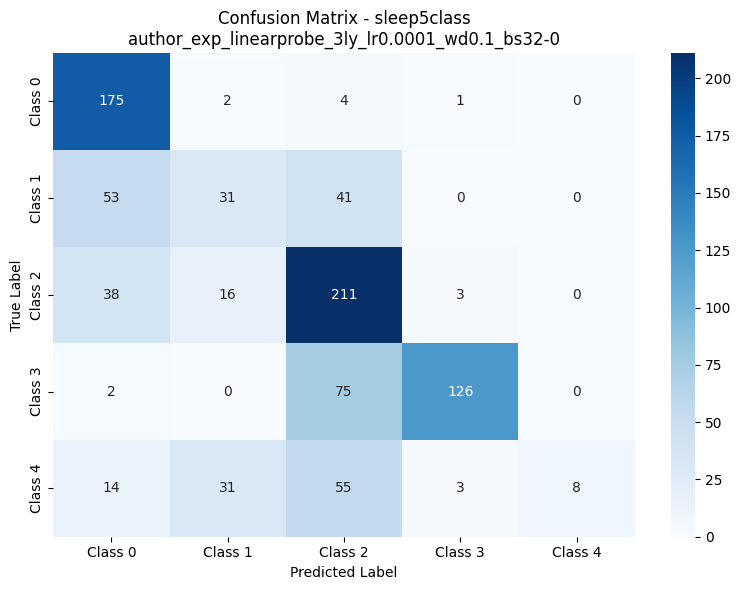


混淆矩阵 (行: 真值, 列: 预测):
[[175   2   4   1   0]
 [ 53  31  41   0   0]
 [ 38  16 211   3   0]
 [  2   0  75 126   0]
 [ 14  31  55   3   8]]

各类别召回率 (行内正确率):
  Class 0: 0.9615  (175/182)
  Class 1: 0.2480  (31/125)
  Class 2: 0.7873  (211/268)
  Class 3: 0.6207  (126/203)
  Class 4: 0.0721  (8/111)


In [3]:
# 根据指定实验名可视化混淆矩阵（通用版）
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 手动指定 =====
# 数据集名称（对应 results 下的子目录，比如 'sleep5class'、'motor6class'）
dataset_name = "sleep5class"  # 修改这里
# 实验名称（results/dataset_name 下的具体实验文件夹名）
exp_name = "author_exp_linearprobe_3ly_lr0.0001_wd0.1_bs32-0"  # 修改这里
# ==================

exp_dir = Path("./results") / dataset_name / exp_name
print(f"实验目录: {exp_dir}")

cm_csv = exp_dir / "test_confusion_matrix.csv"
cm_png = exp_dir / "test_confusion_matrix.png"
predictions_path = exp_dir / "test_predictions.npy"
labels_path = exp_dir / "test_label_ids.npy"

if cm_csv.exists():
    # 直接从训练脚本保存的混淆矩阵 CSV 加载
    cm_df = pd.read_csv(cm_csv, index_col=0)
    cm = cm_df.values
    num_classes = cm.shape[0]
    print("已从 test_confusion_matrix.csv 加载混淆矩阵")
else:
    # 回退方案：从预测和标签重新计算
    if not (predictions_path.exists() and labels_path.exists()):
        raise FileNotFoundError(
            f"找不到混淆矩阵或预测文件\ncm_csv: {cm_csv}\n预测: {predictions_path}\n标签: {labels_path}"
        )
    from sklearn.metrics import confusion_matrix

    preds = np.load(predictions_path)
    labels = np.load(labels_path)

    if preds.ndim > 1 and preds.shape[-1] > 1:
        y_pred = preds.argmax(axis=-1)
    else:
        y_pred = preds
    if labels.ndim > 1:
        y_true = labels.flatten()
    else:
        y_true = labels

    num_classes = int(y_true.max()) + 1
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    cm_df = pd.DataFrame(
        cm,
        index=[f"True {i}" for i in range(num_classes)],
        columns=[f"Pred {i}" for i in range(num_classes)],
    )
    print("已从预测文件重新计算混淆矩阵")

# 可视化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Class {i}" for i in range(num_classes)],
    yticklabels=[f"Class {i}" for i in range(num_classes)],
)
plt.title(f"Confusion Matrix - {dataset_name}\n{exp_name}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 同时打印混淆矩阵和各类别准确率
print("\n混淆矩阵 (行: 真值, 列: 预测):")
print(cm)

print("\n各类别召回率 (行内正确率):")
for i in range(num_classes):
    if cm[i].sum() > 0:
        recall_i = cm[i, i] / cm[i].sum()
        print(f"  Class {i}: {recall_i:.4f}  ({cm[i, i]}/{cm[i].sum()})")

/tmp/ipykernel_441/3051522540.py:36: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:36: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:36: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:36: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPyt

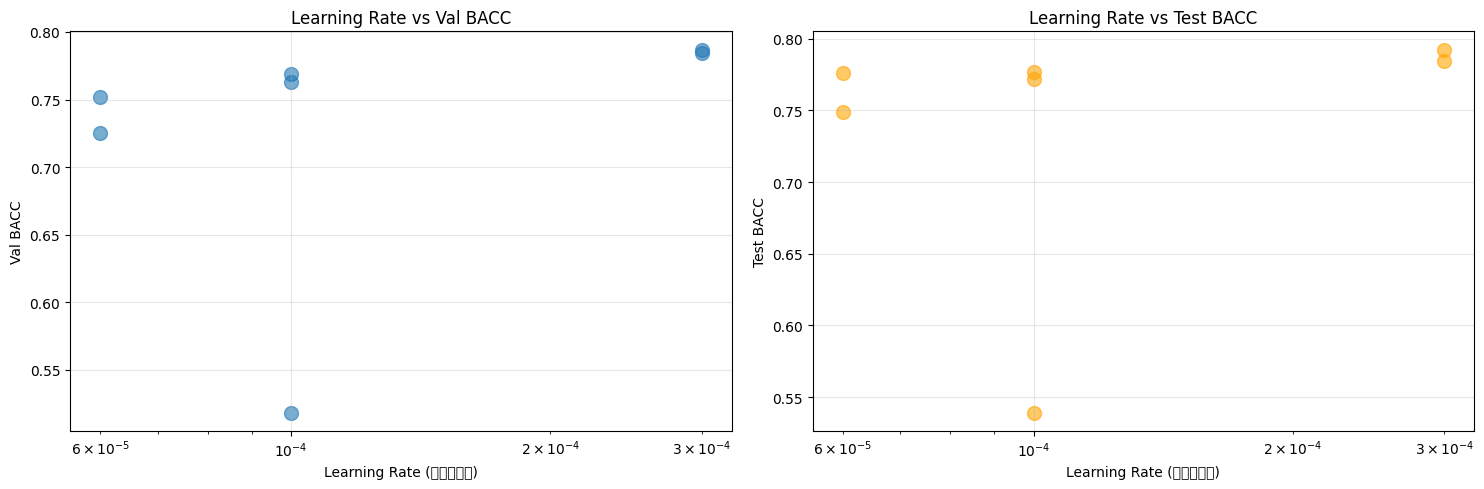

/tmp/ipykernel_441/3051522540.py:57: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:57: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:57: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:57: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_441/3051522540.py:57: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


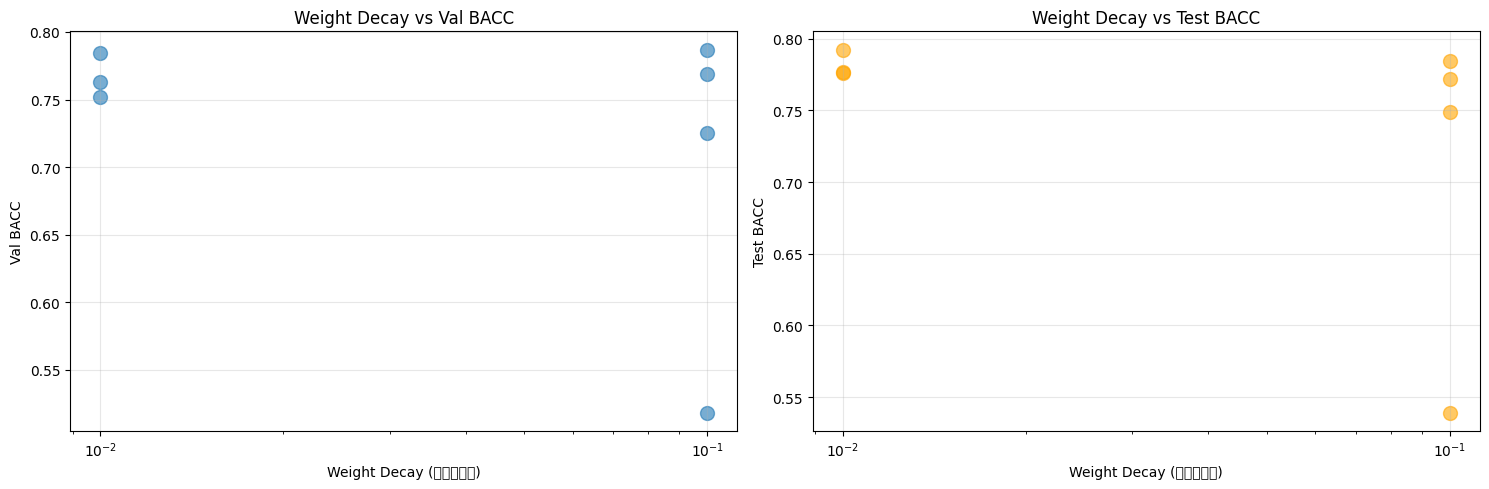

In [4]:
# 可选：绘制超参数与性能的关系图
if len(all_results) > 0:
    # 提取主要超参数和性能
    plot_data = []
    for result in all_results:
        if result['test_bacc'] is not None:
            plot_data.append({
                'LR': result['hyperparams'].get('learning_rate'),
                'WD': result['hyperparams'].get('weight_decay'),
                'BS': result['hyperparams'].get('per_device_training_batch_size'),
                'Val BACC': result['best_val_bacc'],
                'Test BACC': result['test_bacc'],
            })
    
    if len(plot_data) > 0:
        plot_df = pd.DataFrame(plot_data)
        
        # 绘制散点图：学习率 vs 性能
        if 'LR' in plot_df.columns and plot_df['LR'].notna().any():
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            axes[0].scatter(plot_df['LR'], plot_df['Val BACC'], alpha=0.6, s=100)
            axes[0].set_xlabel('Learning Rate (科学计数法)')
            axes[0].set_ylabel('Val BACC')
            axes[0].set_title('Learning Rate vs Val BACC')
            axes[0].set_xscale('log')
            axes[0].grid(True, alpha=0.3)
            
            axes[1].scatter(plot_df['LR'], plot_df['Test BACC'], alpha=0.6, s=100, color='orange')
            axes[1].set_xlabel('Learning Rate (科学计数法)')
            axes[1].set_ylabel('Test BACC')
            axes[1].set_title('Learning Rate vs Test BACC')
            axes[1].set_xscale('log')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        
        # 绘制权重衰减 vs 性能
        if 'WD' in plot_df.columns and plot_df['WD'].notna().any():
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            axes[0].scatter(plot_df['WD'], plot_df['Val BACC'], alpha=0.6, s=100)
            axes[0].set_xlabel('Weight Decay (科学计数法)')
            axes[0].set_ylabel('Val BACC')
            axes[0].set_title('Weight Decay vs Val BACC')
            axes[0].set_xscale('log')
            axes[0].grid(True, alpha=0.3)
            
            axes[1].scatter(plot_df['WD'], plot_df['Test BACC'], alpha=0.6, s=100, color='orange')
            axes[1].set_xlabel('Weight Decay (科学计数法)')
            axes[1].set_ylabel('Test BACC')
            axes[1].set_title('Weight Decay vs Test BACC')
            axes[1].set_xscale('log')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()


# 训练结果分析

分析训练结果：找到最佳验证集bacc，对应的epoch，以及对应的test bacc，并生成混淆矩阵



In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, accuracy_score
from pathlib import Path

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置实验目录路径（请修改为你的实验目录）
experiment_dir = "../results/motor6class/hpo_exp14_3ly_lr3e-4_wd0.1_bs128-0"
experiment_dir = Path(experiment_dir)

# 读取验证集和测试集历史
val_csv_path = experiment_dir / "eval_validation_history.csv"
test_csv_path = experiment_dir / "eval_test_history.csv"

val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path) if test_csv_path.exists() else None

print("验证集历史文件列:", list(val_df.columns))
if test_df is not None:
    print("测试集历史文件列:", list(test_df.columns))
# 找到最佳bacc
# 检查bacc列名
bacc_col = None
for col in val_df.columns:
    if 'bacc' in col.lower():
        bacc_col = col
        break

if bacc_col is None:
    raise ValueError(f"找不到bacc列。可用列: {list(val_df.columns)}")

print(f"使用bacc列: {bacc_col}")

# 找到最佳bacc
best_idx = val_df[bacc_col].idxmax()
best_row = val_df.loc[best_idx]

best_step = int(best_row['step'])
best_bacc = float(best_row[bacc_col])

# 获取epoch（如果有）
if 'epoch' in val_df.columns:
    best_epoch = float(best_row['epoch'])
else:
    best_epoch = best_step  # 临时使用step

print(f"\n{'='*60}")
print("最佳验证集结果:")
print(f"{'='*60}")
print(f"Step: {best_step}")
print(f"Epoch: {best_epoch:.2f}")
print(f"最佳验证集 BACC: {best_bacc:.4f}")

# 显示最佳step时的所有指标
print(f"\n最佳step时的所有验证集指标:")
for col in val_df.columns:
    if col != 'step' and not col.startswith('eval_test'):
        print(f"  {col}: {best_row[col]:.4f}")
# 找到对应的test结果
if test_df is not None:
    test_row = test_df[test_df['step'] == best_step]
    
    if len(test_row) > 0:
        test_row = test_row.iloc[0]
        test_bacc_col = None
        for col in test_df.columns:
            if 'bacc' in col.lower():
                test_bacc_col = col
                break
        
        if test_bacc_col:
            test_bacc = float(test_row[test_bacc_col])
            print(f"\n{'='*60}")
            print("对应的测试集结果:")
            print(f"{'='*60}")
            print(f"Step: {best_step}")
            print(f"测试集 BACC: {test_bacc:.4f}")
            
            # 显示所有test指标
            print(f"\n该step时的所有测试集指标:")
            for col in test_df.columns:
                if col != 'step':
                    print(f"  {col}: {test_row[col]:.4f}")
    else:
        print(f"\n警告: 在测试集历史中找不到step {best_step} 的记录")
        print(f"测试集历史中的step范围: {test_df['step'].min()} - {test_df['step'].max()}")
else:
    print(f"\n未找到测试集历史文件")
# 生成混淆矩阵（如果存在预测结果文件）
predictions_path = experiment_dir / "test_predictions.npy"
labels_path = experiment_dir / "test_label_ids.npy"

if predictions_path.exists() and labels_path.exists():
    predictions = np.load(predictions_path)
    labels = np.load(labels_path)
    
    # 如果predictions是logits，需要转换为类别
    if predictions.ndim > 1 and predictions.shape[-1] > 1:
        pred_labels = np.argmax(predictions, axis=-1)
    else:
        # 如果是二分类的单个logit
        pred_labels = (predictions > 0).astype(int).flatten()
    
    # 确保labels是一维数组
    if labels.ndim > 1:
        labels = labels.flatten()
    
    # 计算混淆矩阵
    cm = confusion_matrix(labels, pred_labels)
    
    # 计算指标
    acc = accuracy_score(labels, pred_labels)
    bacc = balanced_accuracy_score(labels, pred_labels)
    
    print(f"测试集准确率 (Accuracy): {acc:.4f}")
    print(f"测试集平衡准确率 (BACC): {bacc:.4f}")
    
    # 绘制混淆矩阵
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=range(len(cm)), 
               yticklabels=range(len(cm)))
    plt.title(f'混淆矩阵 (Test Set)\nAccuracy: {acc:.4f}, BACC: {bacc:.4f}')
    plt.ylabel('真实标签')
    plt.xlabel('预测标签')
    plt.tight_layout()
    plt.show()
    
    # 打印混淆矩阵
    print(f"\n混淆矩阵:")
    print(cm)
    
    # 计算每个类别的准确率
    print(f"\n各类别准确率:")
    for i in range(len(cm)):
        if cm[i].sum() > 0:
            class_acc = cm[i, i] / cm[i].sum()
            print(f"  类别 {i}: {class_acc:.4f} ({cm[i, i]}/{cm[i].sum()})")
else:
    print(f"未找到预测结果文件，无法生成混淆矩阵")
    print(f"  预测文件: {predictions_path}")
    print(f"  标签文件: {labels_path}")

# 可选：绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 绘制验证集bacc曲线
axes[0].plot(val_df['step'], val_df[bacc_col], label='Validation BACC')
axes[0].axvline(x=best_step, color='r', linestyle='--', label=f'Best (step {best_step})')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('BACC')
axes[0].set_title('Validation BACC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 如果有测试集，也绘制测试集bacc
if test_df is not None:
    test_bacc_col = None
    for col in test_df.columns:
        if 'bacc' in col.lower():
            test_bacc_col = col
            break
    
    if test_bacc_col:
        axes[1].plot(test_df['step'], test_df[test_bacc_col], label='Test BACC', color='orange')
        axes[1].axvline(x=best_step, color='r', linestyle='--', label=f'Best (step {best_step})')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('BACC')
        axes[1].set_title('Test BACC')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

